In [8]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
from tensorflow.keras.utils import to_categorical

In [5]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
columns = ['letter', 'x-box', 'y-box', 'width', 'high', 'onpix', 'x-bar', 'y-bar', 
           'x2bar', 'y2bar', 'xybar', 'x2ybr', 'xy2br', 'x-ege', 'xegvy', 'y-ege', 'yegvx']
df = pd.read_csv(url, header=None, names=columns)
df.head()


,letter,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [6]:
X = df.drop('letter', axis=1).values
y = df['letter'].values

In [9]:
# from tensorflow.keras.models import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_onehot = to_categorical(y_encoded, num_classes=26)


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_onehot, test_size=0.2, random_state=42)


In [12]:
# Build model
model = Sequential()
model.add(Dense(64, input_shape=(16, ), activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(26, activation='softmax'))

In [13]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=30, batch_size=64, validation_split=0.2)



Epoch 1/30


200/200 [==============================] - 15s 19ms/step - loss: 1.8014 - accuracy: 0.5049 - val_loss: 1.0160 - val_accuracy: 0.7075
Epoch 2/30
200/200 [==============================] - 3s 15ms/step - loss: 0.7961 - accuracy: 0.7687 - val_loss: 0.7187 - val_accuracy: 0.7850
Epoch 3/30
200/200 [==============================] - 2s 12ms/step - loss: 0.5863 - accuracy: 0.8287 - val_loss: 0.5629 - val_accuracy: 0.8334
Epoch 4/30
200/200 [==============================] - 2s 11ms/step - loss: 0.4758 - accuracy: 0.8609 - val_loss: 0.4802 - val_accuracy: 0.8506
Epoch 5/30
200/200 [==============================] - 2s 11ms/step - loss: 0.4011 - accuracy: 0.8818 - val_loss: 0.4119 - val_accuracy: 0.8756
Epoch 6/30
200/200 [==============================] - 2s 11ms/step - loss: 0.3462 - accuracy: 0.8958 - val_loss: 0.3550 - val_accuracy: 0.8956
Epoch 7/30
200/200 [==============================] - 2s 9ms/step - loss: 0.3053 - accuracy: 0.9081 - val_loss: 0.3237 - val_accuracy: 0.9

In [15]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test loss: {loss:.4f}, Test accuracy: {acc:.4f}")

125/125 [==============================] - 1s 5ms/step - loss: 0.1756 - accuracy: 0.9430
Test loss: 0.1756, Test accuracy: 0.9430


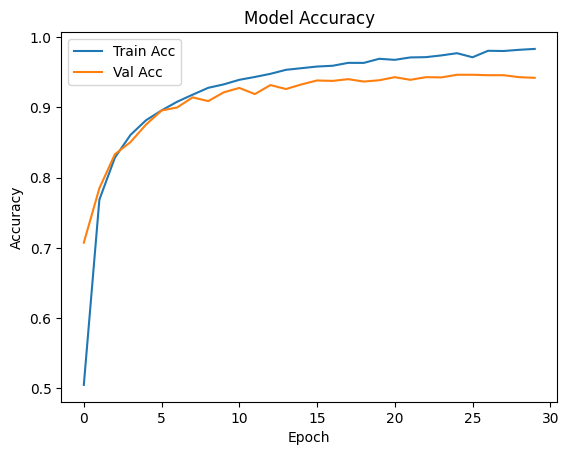

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
